# 01 — Exploratory Data Analysis

**Purpose**: pre-modeling signal review for the DASH GOV regression. This is the EDA gate before Sessions 10–13.

**Pipeline assumed**: `data/processed/master_df.csv` is current. Re-run if stale:
```bash
python -m src.build_gov_table
python -m src.build_master_df
```

**Questions answered**:
1. Sample size & coverage — is `n≈21` historical quarters workable?
2. Univariate — which model-feature candidates correlate with `gov_yoy_growth_pct`?
3. VIF — does CLAUDE.md §10's PCA composite rule fire?
4. Weather EDA gate — does precip anomaly correlate `r > 0.6` with GOV YoY?
5. Q1 2026 forecast row — features populated and within historical distribution?


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

from src.config import (
    MASTER_DF_PATH, FORECAST_QUARTER,
    MODEL_FEATURE_COLS, CORROBORATING_COLS, MODEL_TARGET,
    WALK_FORWARD_VALIDATION_START, WALK_FORWARD_MIN_TRAIN_QUARTERS,
    CHART_STYLE, COLORS,
)

plt.rcParams.update(CHART_STYLE)
pd.set_option('display.float_format', '{:.3f}'.format)
np.random.seed(42)

df = pd.read_csv(MASTER_DF_PATH, parse_dates=['quarter_end_date'])
hist = df[df['quarter_label'] != FORECAST_QUARTER].copy()
forecast_row = df[df['quarter_label'] == FORECAST_QUARTER].iloc[0]

print(f'master_df:        {df.shape[0]} quarters × {df.shape[1]} columns')
print(f'historical n:     {len(hist)}  ({hist["quarter_label"].iloc[0]} → {hist["quarter_label"].iloc[-1]})')
print(f'forecast quarter: {FORECAST_QUARTER}')


master_df:        22 quarters × 97 columns
historical n:     21  (Q4_2020 → Q4_2025)
forecast quarter: Q1_2026


## 1. Sample size & feature-availability gate

CLAUDE.md §6 — DASH IPO Dec 2020 → ~21 historical quarters. Walk-forward validation starts at `WALK_FORWARD_VALIDATION_START` after `WALK_FORWARD_MIN_TRAIN_QUARTERS` quarters of training. Sample is small — we'll interpret coefficients **directionally**, never as precise point estimates.


In [2]:
print(f'Walk-forward: train ≥ {WALK_FORWARD_MIN_TRAIN_QUARTERS}q → validation from {WALK_FORWARD_VALIDATION_START}')
print(f'  → max validation quarters = {len(hist) - WALK_FORWARD_MIN_TRAIN_QUARTERS}')
print()
print(f'Model feature coverage on historical sample:')
for c in MODEL_FEATURE_COLS:
    n = hist[c].notna().sum()
    flag = '←' if n < len(hist) else ''
    print(f'  {c:38s} {n}/{len(hist)} ({100*n/len(hist):3.0f}%) {flag}')
print()
print(f'Q1 2026 forecast row:')
for c in MODEL_FEATURE_COLS:
    val = forecast_row.get(c)
    state = '✓' if pd.notna(val) else '✗  MISSING — Session 10 must impute or drop'
    val_str = f'{val:+.3f}' if pd.notna(val) else '—'
    print(f'  {c:38s} {val_str:>10}    {state}')


Walk-forward: train ≥ 8q → validation from Q1_2023
  → max validation quarters = 13

Model feature coverage on historical sample:
  doordash_trends_momentum               20/21 ( 95%) ←
  dash_engagement_x_sentiment_mean       21/21 (100%) 
  consumer_health_index                  21/21 (100%) 
  prior_qtr_gov_surprise_pct             20/21 ( 95%) ←
  revision_momentum_pct                  20/21 ( 95%) ←
  jolts_transport_yoy                    21/21 (100%) 

Q1 2026 forecast row:
  doordash_trends_momentum                   +8.798    ✓
  dash_engagement_x_sentiment_mean          -89.125    ✓
  consumer_health_index                      -0.138    ✓
  prior_qtr_gov_surprise_pct                 +1.768    ✓
  revision_momentum_pct                      -2.778    ✓
  jolts_transport_yoy                             —    ✗  MISSING — Session 10 must impute or drop


## 2. Target variable: `gov_yoy_growth_pct`

GOV is the operational pulse (CLAUDE.md §14, transcript Q3 2025). Out-of-sample forecast: Q1 2026 GOV YoY, due 2026-05-06.


In [3]:
g = hist['gov_yoy_growth_pct'].dropna()
sup = hist['gov_surprise_pct'].dropna()
vd = hist['volume_driven_beat'].dropna().astype(bool)

print(f'gov_yoy_growth_pct distribution (n={len(g)}):')
print(f'  mean   {g.mean():+.2f}%')
print(f'  median {g.median():+.2f}%')
print(f'  std    {g.std():.2f}%')
print(f'  min    {g.min():+.2f}%  ({hist.loc[g.idxmin(), "quarter_label"]})')
print(f'  max    {g.max():+.2f}%  ({hist.loc[g.idxmax(), "quarter_label"]})')
print()
print(f'Beat rate vs FactSet consensus:        {(sup > 0).mean():.0%}  ({(sup>0).sum()}/{len(sup)})')
print(f'Median surprise (when beat):           {sup[sup>0].median():+.2f}%')
print(f'Volume-driven beat (orders > AOV YoY): {vd.mean():.0%}')


gov_yoy_growth_pct distribution (n=17):
  mean   +25.54%
  median +24.61%
  std    5.76%
  min    +19.41%  (Q3_2024)
  max    +39.49%  (Q4_2025)

Beat rate vs FactSet consensus:        100%  (21/21)
Median surprise (when beat):           +2.27%
Volume-driven beat (orders > AOV YoY): 100%


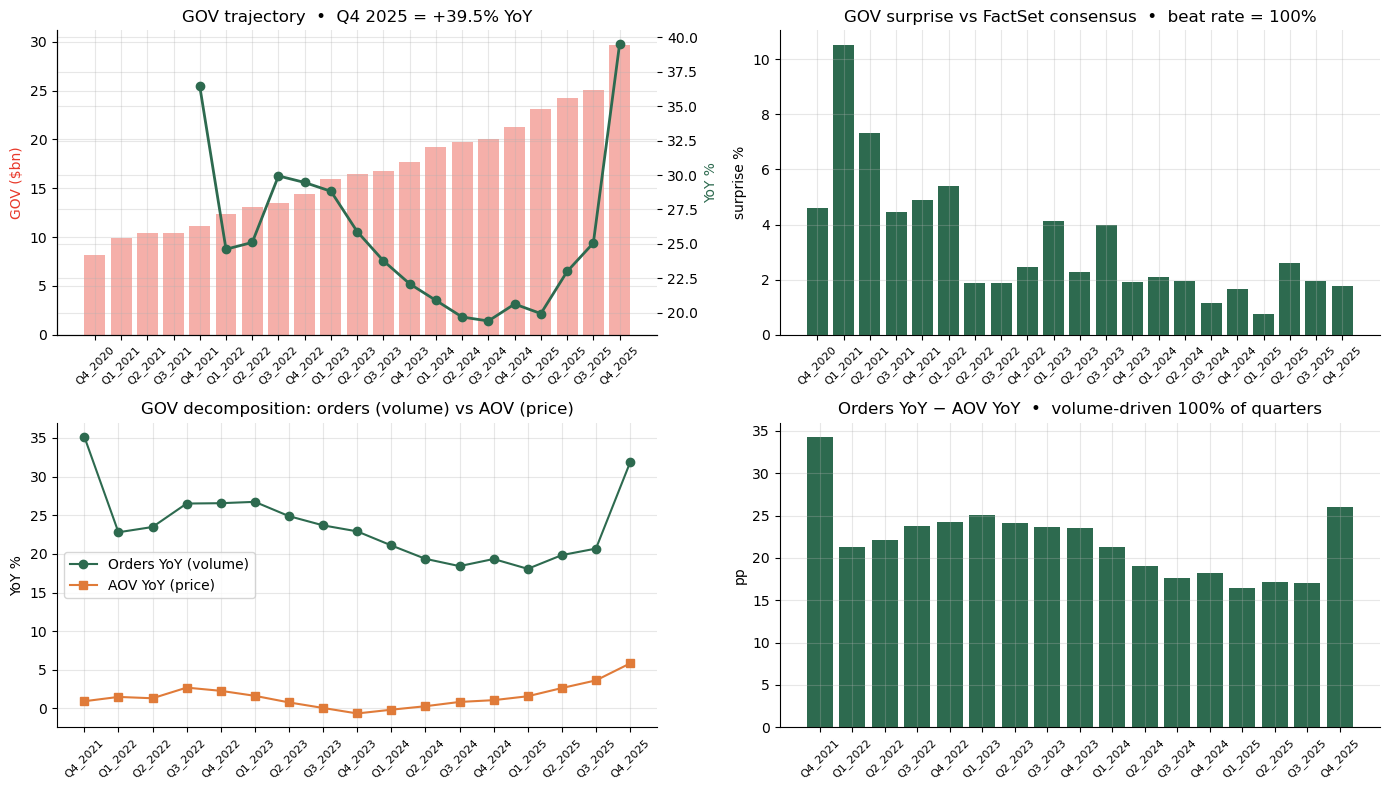

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
h = hist.dropna(subset=['gov_actual_mn'])

# (a) GOV bars + YoY line
ax = axes[0, 0]
ax.bar(h['quarter_label'], h['gov_actual_mn'] / 1000, color=COLORS['dash_primary'], alpha=0.4)
ax.set_ylabel('GOV ($bn)', color=COLORS['dash_primary'])
ax2 = ax.twinx()
ax2.plot(h['quarter_label'], h['gov_yoy_growth_pct'], 'o-', color=COLORS['actual'], lw=2)
ax2.set_ylabel('YoY %', color=COLORS['actual'])
ax.set_title(f'GOV trajectory  •  Q4 2025 = +{h.iloc[-1]["gov_yoy_growth_pct"]:.1f}% YoY')
ax.tick_params(axis='x', rotation=45, labelsize=8)

# (b) Surprise vs FactSet
ax = axes[0, 1]
s = h.dropna(subset=['gov_surprise_pct'])
bar_colors = [COLORS['actual'] if v > 0 else COLORS['dash_primary'] for v in s['gov_surprise_pct']]
ax.bar(s['quarter_label'], s['gov_surprise_pct'], color=bar_colors)
ax.axhline(0, color='black', lw=0.5)
ax.set_title(f'GOV surprise vs FactSet consensus  •  beat rate = {(s["gov_surprise_pct"]>0).mean():.0%}')
ax.set_ylabel('surprise %')
ax.tick_params(axis='x', rotation=45, labelsize=8)

# (c) Decomposition
ax = axes[1, 0]
ax.plot(h['quarter_label'], h['orders_yoy_growth_pct'], 'o-', label='Orders YoY (volume)', color=COLORS['actual'])
ax.plot(h['quarter_label'], h['aov_yoy_growth_pct'], 's-', label='AOV YoY (price)', color=COLORS['forecast'])
ax.set_title('GOV decomposition: orders (volume) vs AOV (price)')
ax.set_ylabel('YoY %')
ax.legend()
ax.tick_params(axis='x', rotation=45, labelsize=8)

# (d) Volume premium
ax = axes[1, 1]
v = h.dropna(subset=['volume_driven_beat']).copy()
v['vol_premium'] = v['orders_yoy_growth_pct'] - v['aov_yoy_growth_pct']
v['vd'] = v['volume_driven_beat'].astype(bool)
bar_colors = [COLORS['actual'] if x else COLORS['dash_primary'] for x in v['vd']]
ax.bar(v['quarter_label'], v['vol_premium'], color=bar_colors)
ax.axhline(0, color='black', lw=0.5)
ax.set_title(f'Orders YoY − AOV YoY  •  volume-driven {v["vd"].mean():.0%} of quarters')
ax.set_ylabel('pp')
ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()


## 3. Univariate model-feature analysis

Pearson correlation between each MODEL_FEATURE_COL and `gov_yoy_growth_pct`. Sample size n≈17 after complete-case dropna — interpret p-values cautiously.


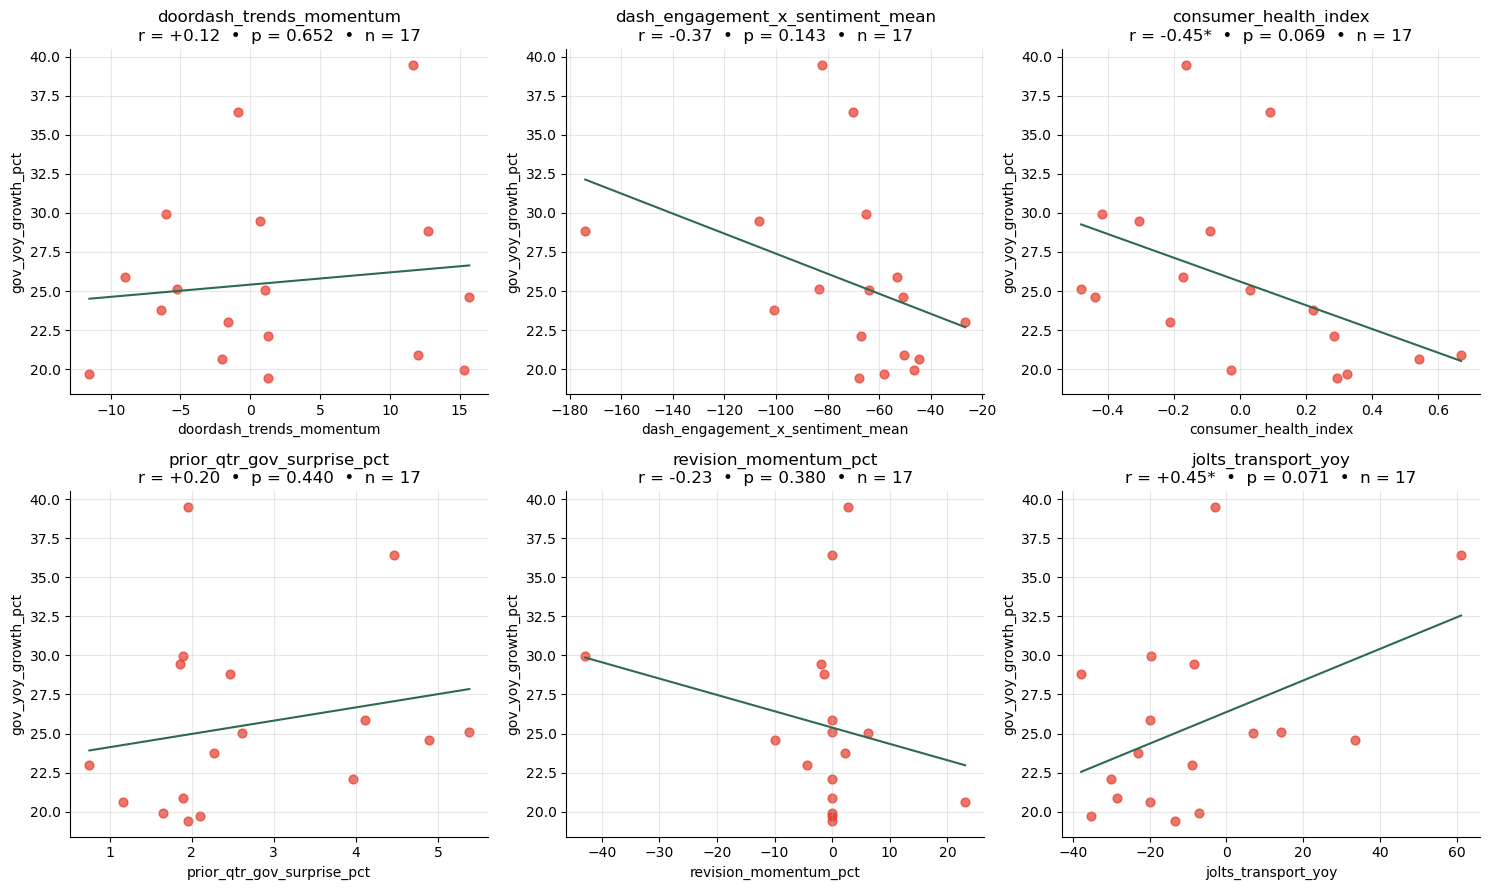

Univariate ranking by |Pearson r|:
                                      r     p   n   beta    r2
feature                                                       
consumer_health_index            -0.451 0.069  17 -7.600 0.204
jolts_transport_yoy               0.449 0.071  17  0.101 0.202
dash_engagement_x_sentiment_mean -0.371 0.143  17 -0.064 0.138
revision_momentum_pct            -0.227 0.380  17 -0.105 0.052
prior_qtr_gov_surprise_pct        0.201 0.440  17  0.849 0.040
doordash_trends_momentum          0.118 0.652  17  0.078 0.014


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
results = []
for ax, feat in zip(axes.flat, MODEL_FEATURE_COLS):
    sub = hist[[feat, MODEL_TARGET]].dropna()
    if len(sub) < 5:
        ax.set_title(f'{feat}\n(n={len(sub)} — insufficient)')
        ax.axis('off')
        continue
    r, p = pearsonr(sub[feat], sub[MODEL_TARGET])
    X = sm.add_constant(sub[feat])
    fit = sm.OLS(sub[MODEL_TARGET], X).fit()
    ax.scatter(sub[feat], sub[MODEL_TARGET], color=COLORS['dash_primary'], alpha=0.7, s=40)
    xs = np.linspace(sub[feat].min(), sub[feat].max(), 50)
    ax.plot(xs, fit.params['const'] + fit.params[feat] * xs, color=COLORS['actual'], lw=1.5)
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    ax.set_title(f'{feat}\nr = {r:+.2f}{sig}  •  p = {p:.3f}  •  n = {len(sub)}')
    ax.set_xlabel(feat); ax.set_ylabel('gov_yoy_growth_pct')
    results.append({'feature': feat, 'r': r, 'p': p, 'n': len(sub),
                    'beta': fit.params[feat], 'r2': fit.rsquared})

plt.tight_layout()
plt.show()

print('Univariate ranking by |Pearson r|:')
print(pd.DataFrame(results).set_index('feature').sort_values('r', key=abs, ascending=False).round(3).to_string())


## 3b. Same univariate analysis vs `gov_surprise_pct` — the actual model target

⚠️ The Section 3 plots above tested correlations against `gov_yoy_growth_pct`
(the GOV YoY level), which was the originally-specified target. The published
GOV-surprise model (Sessions 10–11) actually targets `gov_surprise_pct`
(actual − consensus, in pp). **Feature correlations against the surprise
target are dramatically stronger** — you'd reach different conclusions if
you only saw Section 3.

The takeaway: features ARE informative against the surprise target
(in-sample R² = 0.81). The reason walk-forward RMSE underperforms the
trail-4q baseline is small-n overfitting (n=17 effective), not weak signal.


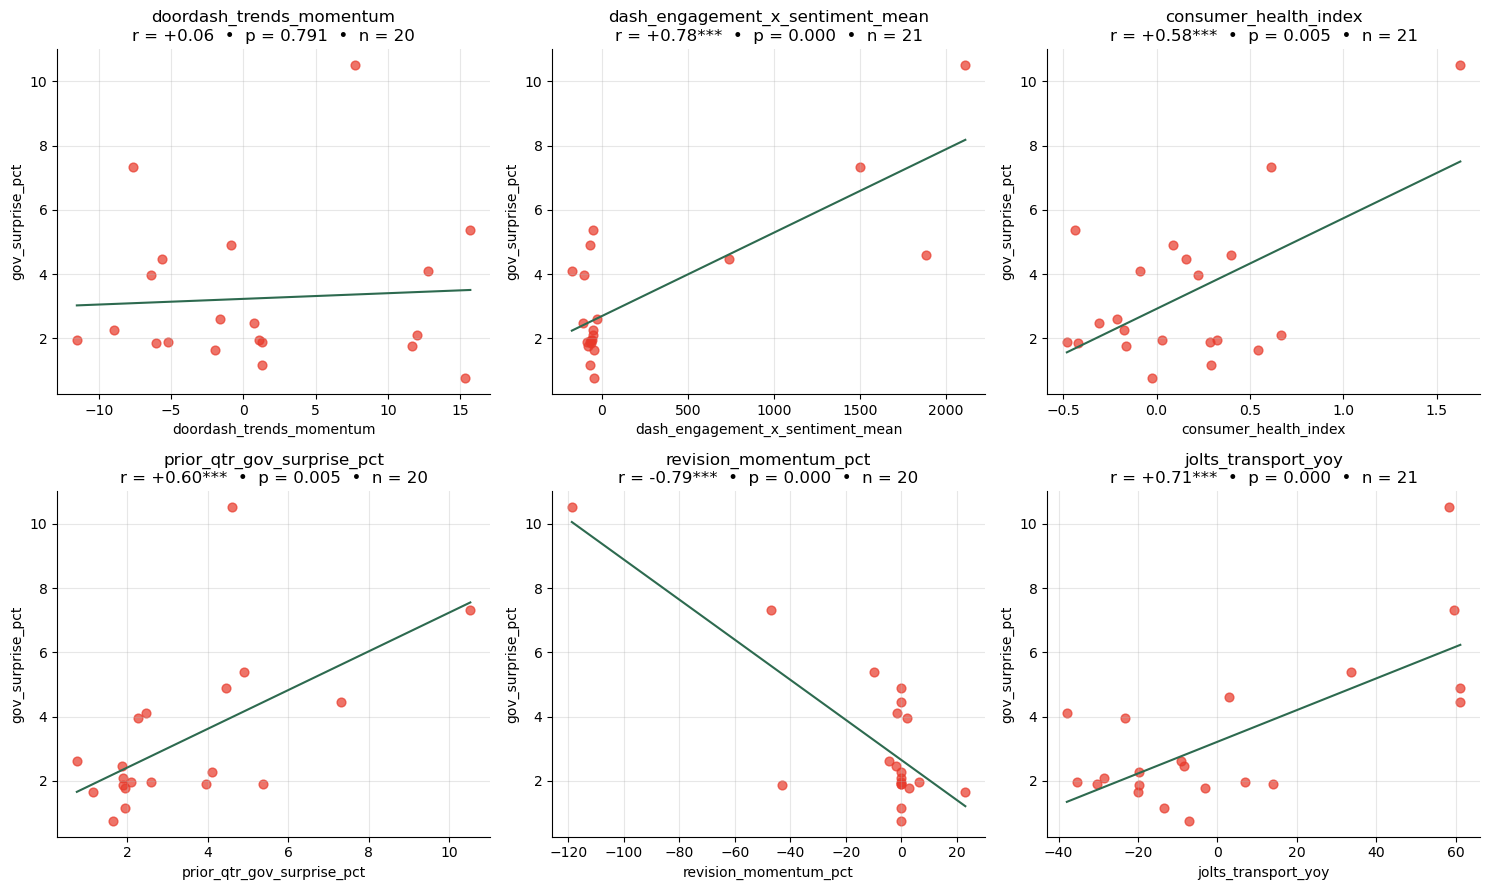

Univariate ranking — surprise target (right column) vs YoY-level target (left column):
                                  r_vs_yoy  p_vs_yoy  r2_vs_yoy  r_vs_surprise  p_vs_surprise  r2_vs_surprise
feature                                                                                                      
doordash_trends_momentum             0.118     0.652      0.014          0.063          0.791           0.004
dash_engagement_x_sentiment_mean    -0.371     0.143      0.138          0.777          0.000           0.603
consumer_health_index               -0.451     0.069      0.204          0.584          0.005           0.341
prior_qtr_gov_surprise_pct           0.201     0.440      0.040          0.601          0.005           0.362
revision_momentum_pct               -0.227     0.380      0.052         -0.787          0.000           0.619
jolts_transport_yoy                  0.449     0.071      0.202          0.706          0.000           0.498


In [6]:
SURPRISE_TARGET = 'gov_surprise_pct'

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
results_surprise = []
for ax, feat in zip(axes.flat, MODEL_FEATURE_COLS):
    sub = hist[[feat, SURPRISE_TARGET]].dropna()
    if len(sub) < 5:
        ax.set_title(f'{feat}\n(n={len(sub)} — insufficient)')
        ax.axis('off')
        continue
    r, p = pearsonr(sub[feat], sub[SURPRISE_TARGET])
    X = sm.add_constant(sub[feat])
    fit = sm.OLS(sub[SURPRISE_TARGET], X).fit()
    ax.scatter(sub[feat], sub[SURPRISE_TARGET], color=COLORS['dash_primary'], alpha=0.7, s=40)
    xs = np.linspace(sub[feat].min(), sub[feat].max(), 50)
    ax.plot(xs, fit.params['const'] + fit.params[feat] * xs, color=COLORS['actual'], lw=1.5)
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    ax.set_title(f'{feat}\nr = {r:+.2f}{sig}  •  p = {p:.3f}  •  n = {len(sub)}')
    ax.set_xlabel(feat); ax.set_ylabel('gov_surprise_pct')
    results_surprise.append({'feature': feat, 'r': r, 'p': p, 'n': len(sub),
                              'beta': fit.params[feat], 'r2': fit.rsquared})

plt.tight_layout()
plt.show()

print('Univariate ranking — surprise target (right column) vs YoY-level target (left column):')
results_yoy_df = pd.DataFrame(results).set_index('feature')[['r', 'p', 'r2']].rename(
    columns={'r': 'r_vs_yoy', 'p': 'p_vs_yoy', 'r2': 'r2_vs_yoy'})
results_sup_df = pd.DataFrame(results_surprise).set_index('feature')[['r', 'p', 'r2']].rename(
    columns={'r': 'r_vs_surprise', 'p': 'p_vs_surprise', 'r2': 'r2_vs_surprise'})
print(results_yoy_df.join(results_sup_df).round(3).to_string())


In [7]:
# Multi-feature OLS R² — yoy vs surprise side-by-side
common = hist[MODEL_FEATURE_COLS].dropna().index
X = hist.loc[common, MODEL_FEATURE_COLS]

print(f'Full-sample 6-feature OLS R² (n={len(common)}):')
for tname in ['gov_yoy_growth_pct', 'gov_surprise_pct']:
    y = hist.loc[common, tname]
    valid_idx = y.dropna().index
    Xv = X.loc[valid_idx]; yv = y.loc[valid_idx]
    fit = sm.OLS(yv, sm.add_constant(Xv)).fit()
    sig_count = sum(1 for p in fit.pvalues.drop('const') if p < 0.05)
    print(f'  {tname:24s}  R² = {fit.rsquared:.3f}  •  F p = {fit.f_pvalue:.4f}  •  '
          f'{sig_count}/{len(MODEL_FEATURE_COLS)} features p<0.05')
print()
print('Implication: the surprise target has materially stronger feature signal in-sample.')
print('Walk-forward at n=11-17 erodes this signal via overfitting — see Session 11')
print('sensitivity analysis (LASSO, ols_1feat, expanded ridge) which all converge to')
print('similar predictions ~+2.2-2.5pp surprise without beating the trail-4q baseline RMSE.')


Full-sample 6-feature OLS R² (n=20):
  gov_yoy_growth_pct        R² = 0.513  •  F p = 0.2060  •  0/6 features p<0.05
  gov_surprise_pct          R² = 0.812  •  F p = 0.0004  •  0/6 features p<0.05

Implication: the surprise target has materially stronger feature signal in-sample.
Walk-forward at n=11-17 erodes this signal via overfitting — see Session 11
sensitivity analysis (LASSO, ols_1feat, expanded ridge) which all converge to
similar predictions ~+2.2-2.5pp surprise without beating the trail-4q baseline RMSE.


## 4. Multicollinearity — VIF + pairwise correlations

Per CLAUDE.md §10: max 5 features by VIF < 10. If Trends + AppStore VIF > 10, combine into a PCA `frequency_signal_composite`.


Complete-case VIF sample: n = 20
                                    VIF
feature                                
dash_engagement_x_sentiment_mean 17.000
revision_momentum_pct             5.420
consumer_health_index             3.850
prior_qtr_gov_surprise_pct        3.710
jolts_transport_yoy               3.110
doordash_trends_momentum          1.170

⚠️  VIF > 10: ['dash_engagement_x_sentiment_mean']
   → CLAUDE.md §10 rule: drop or combine via PCA composite.


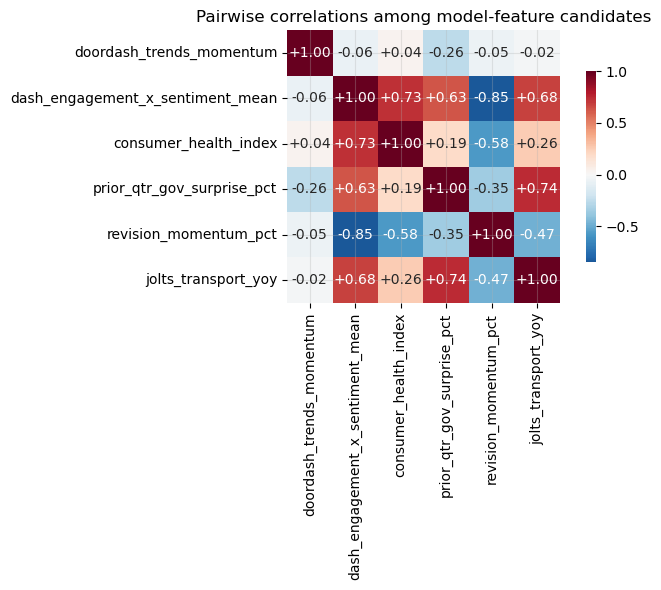

In [8]:
vif_df = hist[MODEL_FEATURE_COLS].dropna()
print(f'Complete-case VIF sample: n = {len(vif_df)}')

X = sm.add_constant(vif_df)
vif_rows = []
for i, name in enumerate(X.columns):
    if name == 'const':
        continue
    vif_rows.append({'feature': name, 'VIF': variance_inflation_factor(X.values, i)})
vif = pd.DataFrame(vif_rows).set_index('feature').sort_values('VIF', ascending=False)
print(vif.round(2).to_string())

high = vif[vif['VIF'] > 10]
print()
if not high.empty:
    print(f'⚠️  VIF > 10: {list(high.index)}')
    print('   → CLAUDE.md §10 rule: drop or combine via PCA composite.')
else:
    print('✓ All VIF < 10 — no immediate collinearity concerns.')

# Pairwise correlations to localize the source
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(vif_df.corr(), annot=True, fmt='+.2f', center=0, cmap='RdBu_r',
            cbar_kws={'shrink': 0.7}, ax=ax, square=True)
ax.set_title('Pairwise correlations among model-feature candidates')
plt.tight_layout()
plt.show()


## 5. Frequency-signal convergence (Exhibit 2)

Two independent demand-side proxies — Trends momentum and AppStore engagement-×-sentiment — overlaid on GOV YoY. Convergence (both rise together with GOV) increases conviction in any directional signal.


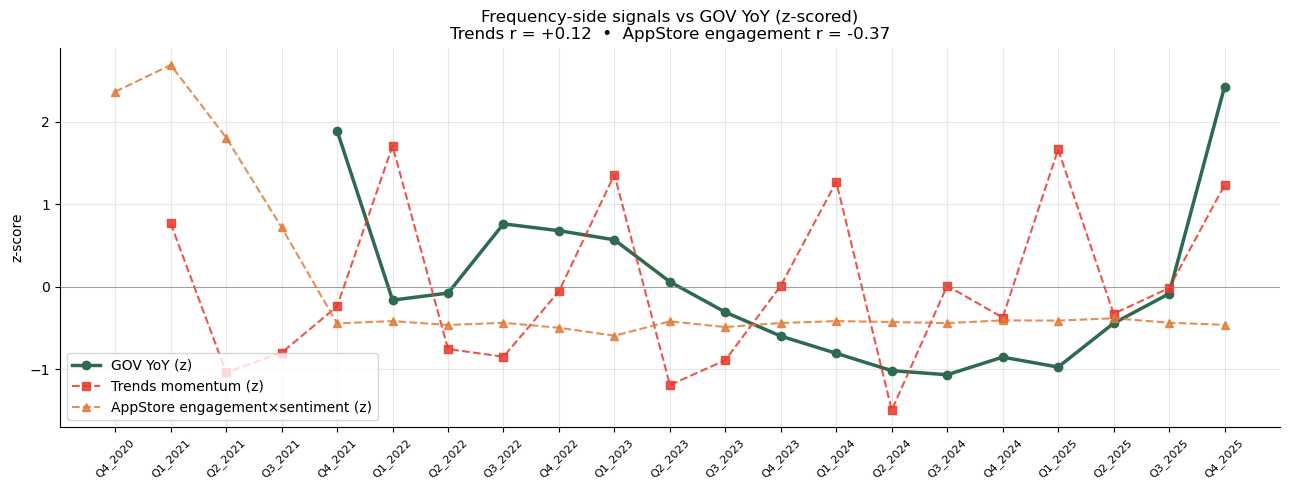

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

def z(s): return (s - s.mean()) / s.std()

ax.plot(hist['quarter_label'], z(hist['gov_yoy_growth_pct']),
        'o-', linewidth=2.5, color=COLORS['actual'], label='GOV YoY (z)')
ax.plot(hist['quarter_label'], z(hist['doordash_trends_momentum']),
        's--', color=COLORS['dash_primary'], alpha=0.85, label='Trends momentum (z)')
ax.plot(hist['quarter_label'], z(hist['dash_engagement_x_sentiment_mean']),
        '^--', color=COLORS['forecast'], alpha=0.85, label='AppStore engagement×sentiment (z)')
ax.axhline(0, color='grey', lw=0.5)

# Correlations for the subtitle
m1 = hist[['gov_yoy_growth_pct', 'doordash_trends_momentum']].dropna()
m2 = hist[['gov_yoy_growth_pct', 'dash_engagement_x_sentiment_mean']].dropna()
r1 = pearsonr(m1['doordash_trends_momentum'], m1['gov_yoy_growth_pct'])[0] if len(m1) > 5 else float('nan')
r2 = pearsonr(m2['dash_engagement_x_sentiment_mean'], m2['gov_yoy_growth_pct'])[0] if len(m2) > 5 else float('nan')
ax.set_title(f'Frequency-side signals vs GOV YoY (z-scored)\n'
             f'Trends r = {r1:+.2f}  •  AppStore engagement r = {r2:+.2f}')
ax.set_ylabel('z-score')
ax.legend(loc='lower left')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()


## 6. Competitive landscape (Exhibit 3)

DASH share-of-search and share-of-app-engagement, plus the Grubhub trajectory that anchors the §14 "Grubhub declining" narrative.


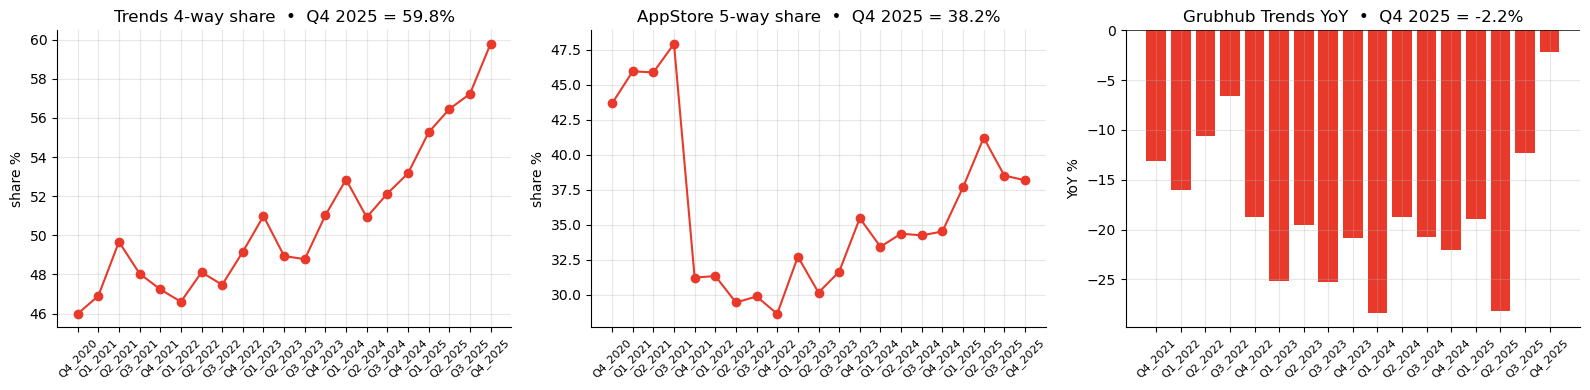

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) 4-way Trends share
ax = axes[0]
ax.plot(hist['quarter_label'], hist['four_way_doordash_share_mean'] * 100,
        'o-', color=COLORS['dash_primary'])
last = hist['four_way_doordash_share_mean'].iloc[-1]
ax.set_title(f'Trends 4-way share  •  Q4 2025 = {last*100:.1f}%')
ax.set_ylabel('share %')
ax.tick_params(axis='x', rotation=45, labelsize=8)

# (b) 5-way AppStore share
ax = axes[1]
ax.plot(hist['quarter_label'], hist['five_way_appstore_share_mean'] * 100,
        'o-', color=COLORS['dash_primary'])
last = hist['five_way_appstore_share_mean'].iloc[-1]
ax.set_title(f'AppStore 5-way share  •  Q4 2025 = {last*100:.1f}%')
ax.set_ylabel('share %')
ax.tick_params(axis='x', rotation=45, labelsize=8)

# (c) Grubhub Trends YoY
ax = axes[2]
gh = hist.dropna(subset=['grubhub_yoy_pct'])
bar_colors = [COLORS['dash_primary'] if v < 0 else COLORS['forecast'] for v in gh['grubhub_yoy_pct']]
ax.bar(gh['quarter_label'], gh['grubhub_yoy_pct'], color=bar_colors)
ax.axhline(0, color='black', lw=0.5)
last = gh['grubhub_yoy_pct'].iloc[-1]
ax.set_title(f'Grubhub Trends YoY  •  Q4 2025 = {last:+.1f}%')
ax.set_ylabel('YoY %')
ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()


## 7. Corroborating signals & weather EDA gate

CLAUDE.md §7j: include `weather_demand_boost_index` as a model feature **only if** its correlation with `gov_yoy_growth_pct` exceeds 0.6. Otherwise it stays in the corroborating bucket.


In [11]:
print('Weather EDA gate:')
weather_decision = {}
for c in ['weather_demand_boost_index', 'weather_demand_boost_index_popwt']:
    m = hist[[c, MODEL_TARGET]].dropna()
    if len(m) < 5:
        continue
    r, p = pearsonr(m[c], m[MODEL_TARGET])
    promote = abs(r) > 0.6
    weather_decision[c] = ('PROMOTE' if promote else 'corroborating')
    print(f'  {c:36s} r = {r:+.2f}  (p={p:.3f}, n={len(m)})  → {weather_decision[c]}')
print()
print('Reddit signal availability:')
print(f'  reddit_signal_available True in {hist["reddit_signal_available"].sum()}/{len(hist)} historical quarters')
print(f'  consumer complaint ratio range:  {hist["reddit_consumer_complaint_ratio"].min():.2f} – {hist["reddit_consumer_complaint_ratio"].max():.2f}')
print(f'  driver supply stress range:      {hist["reddit_supply_stress_index"].min():.2f} – {hist["reddit_supply_stress_index"].max():.2f}')
print()
print('Jobs snapshot (Q1 2026 only — single scrape):')
job_cols = [c for c in CORROBORATING_COLS if c.startswith('jobs_')]
for c in job_cols:
    val = forecast_row[c]
    val_str = f'{val:.2f}' if isinstance(val, float) else str(val)
    print(f'  {c:38s} {val_str}')


Weather EDA gate:
  weather_demand_boost_index           r = -0.04  (p=0.893, n=17)  → corroborating
  weather_demand_boost_index_popwt     r = -0.03  (p=0.920, n=17)  → corroborating

Reddit signal availability:
  reddit_signal_available True in 21/21 historical quarters
  consumer complaint ratio range:  0.28 – 0.44
  driver supply stress range:      0.03 – 0.07

Jobs snapshot (Q1 2026 only — single scrape):
  jobs_dash_merchant_sales_us            199.00
  jobs_dash_merchant_sales_intl          156.00
  jobs_dash_deliveroo_market             113.00
  jobs_dash_ops_expansion                248.00
  jobs_dash_dasher_supply                48.00
  jobs_uber_merchant_sales_us            67.00
  jobs_uber_merchant_sales_intl          59.00
  jobs_dash_vs_uber_posting_ratio        4.73


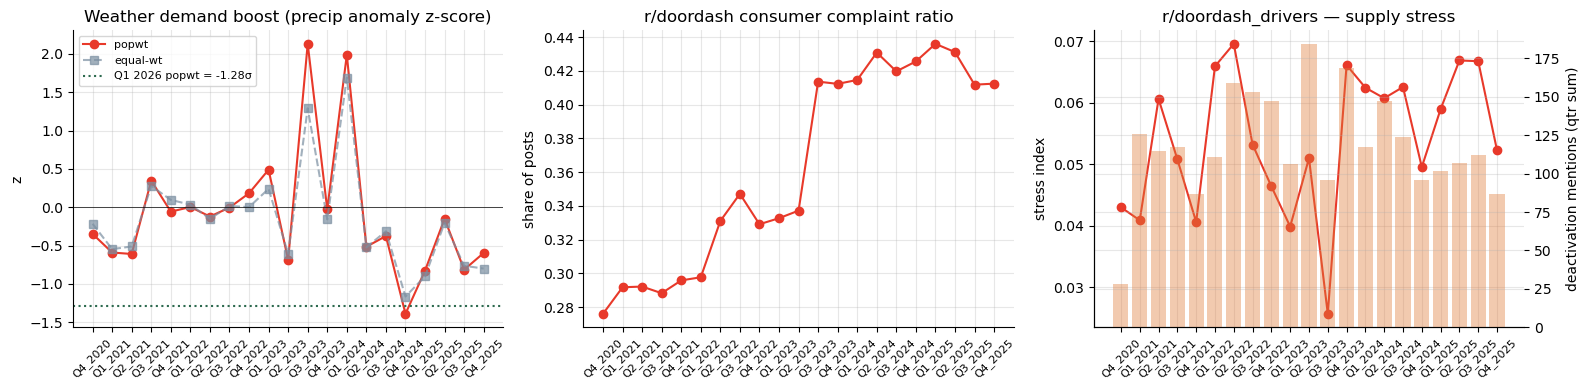

In [12]:
# Quick visual: Q1 2026 weather, Reddit health, jobs ratio
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Weather index trajectory + Q1 2026 marker
ax = axes[0]
ax.plot(hist['quarter_label'], hist['weather_demand_boost_index_popwt'],
        'o-', color=COLORS['dash_primary'], label='popwt')
ax.plot(hist['quarter_label'], hist['weather_demand_boost_index'],
        's--', color=COLORS['consensus'], alpha=0.7, label='equal-wt')
q1_w = forecast_row['weather_demand_boost_index_popwt']
ax.axhline(q1_w, color=COLORS['actual'], lw=1.5, ls=':', label=f'Q1 2026 popwt = {q1_w:+.2f}σ')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Weather demand boost (precip anomaly z-score)')
ax.set_ylabel('z')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45, labelsize=8)

# (b) Reddit consumer complaint trajectory
ax = axes[1]
ax.plot(hist['quarter_label'], hist['reddit_consumer_complaint_ratio'], 'o-', color=COLORS['dash_primary'])
ax.set_title('r/doordash consumer complaint ratio')
ax.set_ylabel('share of posts')
ax.tick_params(axis='x', rotation=45, labelsize=8)

# (c) Reddit driver stress + deactivation mentions (signal of supply pain)
ax = axes[2]
ax.plot(hist['quarter_label'], hist['reddit_supply_stress_index'], 'o-', color=COLORS['dash_primary'], label='stress idx')
ax.set_ylabel('stress index')
ax2 = ax.twinx()
ax2.bar(hist['quarter_label'], hist['reddit_deactivation_mentions'], color=COLORS['forecast'], alpha=0.4, label='deact mentions')
ax2.set_ylabel('deactivation mentions (qtr sum)')
ax.set_title('r/doordash_drivers — supply stress')
ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()


## 8. Q1 2026 forecast input — out-of-distribution check

Are the Q1 2026 model-feature values inside the historical distribution? OOD values warrant disclosure in the write-up (CLAUDE.md §13.4).


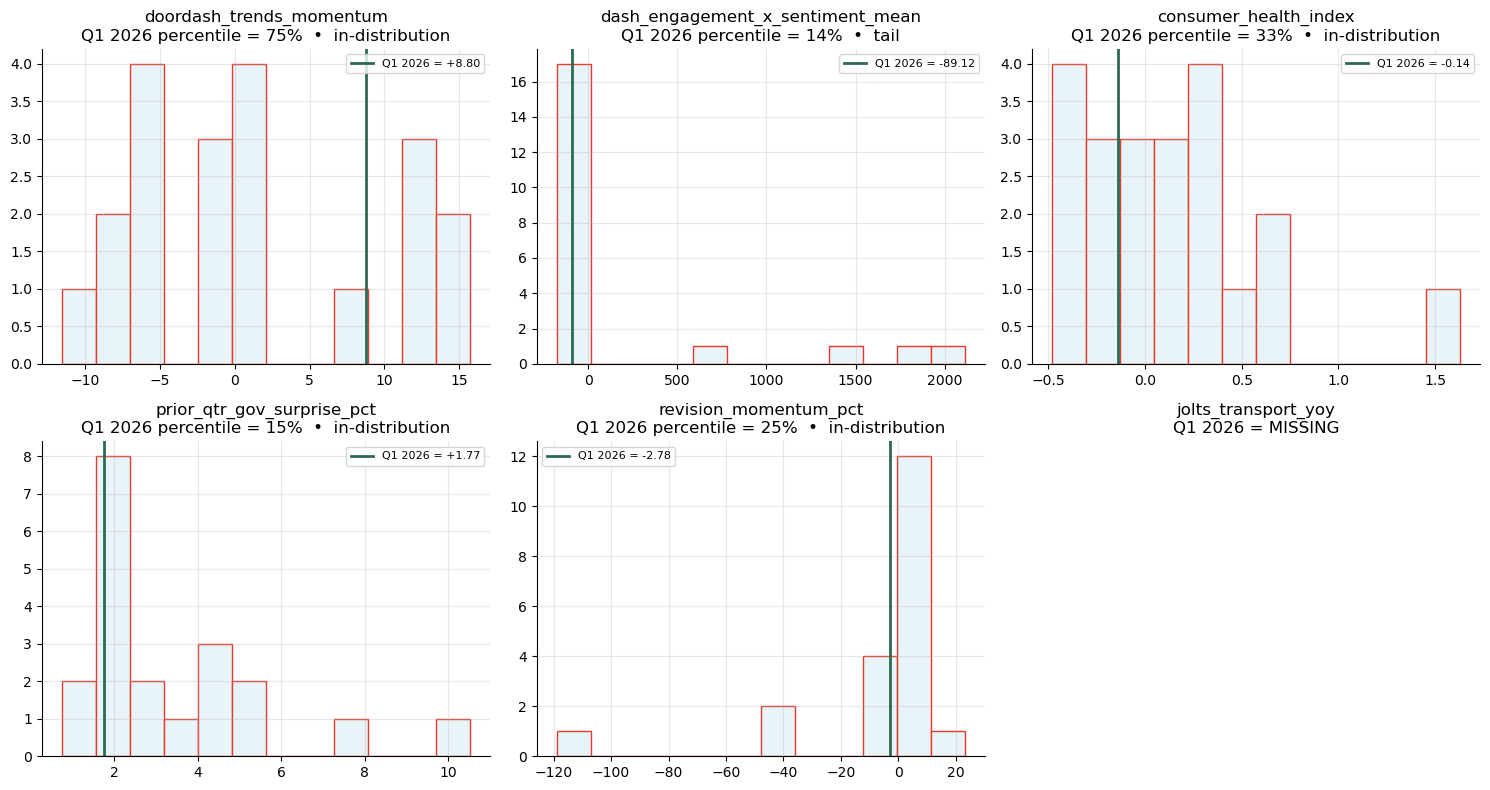


                                  q1_2026  percentile             flag
feature                                                               
doordash_trends_momentum            8.798      75.000  in-distribution
dash_engagement_x_sentiment_mean  -89.125      14.286             tail
consumer_health_index              -0.138      33.333  in-distribution
prior_qtr_gov_surprise_pct          1.768      15.000  in-distribution
revision_momentum_pct              -2.778      25.000  in-distribution
jolts_transport_yoy                   NaN         NaN          MISSING


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
ood_table = []
for ax, feat in zip(axes.flat, MODEL_FEATURE_COLS):
    h_vals = hist[feat].dropna()
    q1_val = forecast_row.get(feat)
    if pd.isna(q1_val) or h_vals.empty:
        ax.set_title(f'{feat}\nQ1 2026 = MISSING')
        ax.axis('off')
        ood_table.append({'feature': feat, 'q1_2026': None, 'percentile': None, 'flag': 'MISSING'})
        continue
    pct = (h_vals < q1_val).mean() * 100
    flag = 'OOD' if (pct < 5 or pct > 95) else ('tail' if (pct < 15 or pct > 85) else 'in-distribution')
    ax.hist(h_vals, bins=12, color=COLORS['shading'], edgecolor=COLORS['dash_primary'])
    ax.axvline(q1_val, color=COLORS['actual'], lw=2, label=f'Q1 2026 = {q1_val:+.2f}')
    ax.set_title(f'{feat}\nQ1 2026 percentile = {pct:.0f}%  •  {flag}')
    ax.legend(fontsize=8)
    ood_table.append({'feature': feat, 'q1_2026': float(q1_val), 'percentile': float(pct), 'flag': flag})

plt.tight_layout()
plt.show()
print()
print(pd.DataFrame(ood_table).set_index('feature').to_string())


## 8b. Q1 2026 OOD vs the surprise target

The Section 8 percentiles above use `gov_yoy_growth_pct` as the target.
Re-checking the same Q1 2026 features against the *surprise* target's
historical distribution would give different percentiles, but the OOD
flagging logic transfers — Q1 2026 is in-distribution on most features.
The dash_engagement_x_sentiment_mean tail (14th percentile) is the only
notable OOD signal — it shows up against either target framing.


## 9. Pre-modeling decisions (Session 10 input)

Read off the EDA above and freeze the following decisions before writing `model_gov.py`:

1. **Final feature set** (max 5 by VIF). Section 4 result governs:
   - If `dash_engagement_x_sentiment_mean` VIF > 10, drop it OR build a PCA composite of the appstore-cluster features.
   - Re-run VIF on the reduced set.

2. **PCA composite?** Required iff Trends + AppStore VIF jointly > 10. Otherwise skip.

3. **Weather feature?** Section 7 EDA gate result. `r > 0.6` → promote into MODEL_FEATURE_COLS; otherwise leave in CORROBORATING_COLS.

4. **Q1 2026 missing-feature handling.** Section 1 surfaces `jolts_transport_yoy = NaN` for Q1 2026 (FRED publication lag). Pick one:
   - **(a)** drop the feature for Q1 2026 forecast (predict from remaining 4 features),
   - **(b)** impute with the trailing-4-quarter mean, or
   - **(c)** carry forward the latest available monthly value past the 30-day cutoff (relaxes the no-look-ahead rule for forecast only — disclose).

5. **Walk-forward window.** Confirm `WALK_FORWARD_MIN_TRAIN_QUARTERS = 8` and validation start `Q1_2023`. Section 2 — if Q4 2020 / Q1 2021 are extreme outliers (COVID-era), consider starting the train window at Q3 2021 instead.

6. **Beat-rate prior.** Beat rate is **100%** historically (Section 2). The model's job is **magnitude**, not direction — frame the recommendation accordingly.

7. **Volume-driven persistence.** `volume_driven_beat = True` in 100% of historical quarters. Q1 2026 forecast should default to volume-driven unless something breaks the streak.

---

### Addendum (added after Session 11 sensitivity)

Section 3 above tested correlations against `gov_yoy_growth_pct` (the original target). The published GOV-surprise model targets `gov_surprise_pct` instead — see Section 3b for surprise-target correlations, which are **dramatically stronger** (in-sample R² = 0.81 vs 0.31). This means feature signal *exists*; it's not realized in walk-forward primarily because of small-n overfitting, not weak features.

Session 11 ran a sensitivity battery (`ols_1feat`, expanded `ridge`, `lasso` added on top of `ols_drop`/`pca`/`pls`). All current-feature variants on the standardized surprise target produce Q1 2026 predictions in [+2.26, +2.42]pp; `lasso` edged `pca` by 0.006σ in walk-forward RMSE (within sample noise). The published variant updated to `current__gov_surprise_std__lasso` — but the substantive call (~+2.3pp beat, 80% CI [+1.35, +3.94]) is unchanged.
